In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"✅ Project path added successfully: {PROJECT_ROOT}")

✅ Project path added successfully: E:\GithubProjects\AI-Resume-Analyzer-Agent


In [16]:
from utils.config_loader import load_config

CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
config = load_config(CONFIG_PATH)

print(config)

{'provider': 'openai', 'openai': {'model': 'gpt-4o-mini', 'temperature': 0, 'max_completion_tokens': 1000}}


In [17]:
from utils.llm_loader import load_llm

llm = load_llm(config)
print(type(llm))

<class 'langchain_openai.chat_models.base.ChatOpenAI'>


In [18]:
from langgraph.graph import StateGraph, START, END
from schemas.resume_analyze_state_schema import ResumeAnalyzeState

In [19]:
from nodes.resume_processer_node import resume_processor_node
from nodes.resume_content_extractor_node import make_resume_content_extractor_node
from nodes.jd_extractor_node import make_jd_extractor_node
from nodes.ats_evaluator_node import make_ats_evaluator_node
from nodes.recommendations_node import make_recommendations_node
from nodes.final_report_node import final_report_node

In [20]:
builder = StateGraph(state_schema=ResumeAnalyzeState)
builder.add_node("Resume Pre-processor", resume_processor_node)
builder.add_node("Resume Content Extractor", make_resume_content_extractor_node(llm))
builder.add_node("Job Description Extractor", make_jd_extractor_node(llm))
builder.add_node("ATS Evaluator", make_ats_evaluator_node(llm))
builder.add_node("Recommendations Generator", make_recommendations_node(llm))
builder.add_node("Report Generation", final_report_node(llm))

builder.add_edge(START, "Resume Pre-processor")
builder.add_edge("Resume Pre-processor", "Resume Content Extractor")
builder.add_edge("Resume Pre-processor", "Job Description Extractor")
builder.add_edge("Job Description Extractor", "ATS Evaluator")
builder.add_edge("Resume Content Extractor", "ATS Evaluator")
builder.add_edge("ATS Evaluator", "Recommendations Generator")
builder.add_edge("Recommendations Generator", "Report Generation")
builder.add_edge("Report Generation", END)

In [21]:
graph = builder.compile()

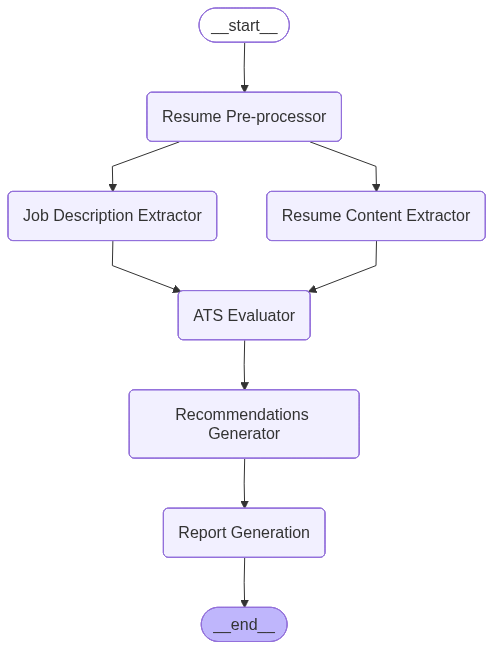

In [22]:
def display_graph(graph):
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))

display_graph(graph)

In [23]:
job_description = """
𝗝𝗼𝗶𝗻 𝗦𝗿𝗼𝗻𝗶𝘆𝗮𝗻 𝗧𝗲𝗰𝗵𝗻𝗼𝗹𝗼𝗴𝘆 — 𝗕𝘂𝗶𝗹𝗱 𝘁𝗵𝗲 𝗡𝗲𝘅𝘁 𝗚𝗲𝗻𝗲𝗿𝗮𝘁𝗶𝗼𝗻 𝗼𝗳 𝗔𝗜

𝗪𝗲'𝗿𝗲 𝗛𝗶𝗿𝗶𝗻𝗴: 𝗔𝗜 𝗘𝗻𝗴𝗶𝗻𝗲𝗲𝗿 (𝗟𝟭)
📍 𝗪𝗼𝗿𝗸 𝗠𝗼𝗱𝗲: 𝗥𝗲𝗺𝗼𝘁𝗲
🗓️ 𝗘𝘅𝗽𝗲𝗿𝗶𝗲𝗻𝗰𝗲: 𝟮–𝟲 𝗬𝗲𝗮𝗿𝘀
⚡ 𝗣𝗿𝗲𝗳𝗲𝗿𝗲𝗻𝗰𝗲: 𝗜𝗺𝗺𝗲𝗱𝗶𝗮𝘁𝗲 𝗝𝗼𝗶𝗻𝗲𝗿𝘀

Are you passionate about Artificial Intelligence, Machine Learning, LLMs, and Agentic AI? 

At Sroniyan Technology, we're building intelligent AI solutions that solve real business challenges. We're looking for a motivated and enthusiastic Junior AI Engineer who is eager to work on cutting-edge AI products, collaborate with experienced professionals, and contribute to end-to-end product development.

If you're someone who enjoys learning, experimenting, and building production-ready AI applications, we'd love to connect with you.

💼 𝗞𝗲𝘆 𝗥𝗲𝘀𝗽𝗼𝗻𝘀𝗶𝗯𝗶𝗹𝗶𝘁𝗶𝗲𝘀

🔹 Develop and support AI/ML solutions from data preparation and model development to evaluation and deployment.
🔹 Build LLM-powered applications and Agentic AI workflows, including tool integration, function calling, and multi-step reasoning.
🔹 Understand business and client requirements, translate them into technical solutions, and support successful project delivery.
🔹 Design, build, and maintain REST APIs for AI services using modern Python frameworks.
🔹 Collaborate with cross-functional teams to improve product performance, quality, scalability, and reliability.

✅ 𝗥𝗲𝗾𝘂𝗶𝗿𝗲𝗱 𝗦𝗸𝗶𝗹𝗹𝘀 

✔ 2–6 years of professional experience.
✔ Minimum 2 years of hands-on experience in AI/ML.
✔ Minimum 3 years of hands-on experience with LLMs and Agentic AI.
✔ Strong proficiency in Python with solid software development fundamentals.
✔ Experience building REST APIs using FastAPI, Flask, Django REST, or similar frameworks.
✔ Experience working with at least one cloud platform:
AWS • Azure • GCP
✔ Experience with Docker and basic knowledge of Kubernetes.
✔ Strong analytical, problem-solving, and communication skills.
✔ Ability to understand business requirements and communicate technical solutions effectively.

⭐ 𝗕𝗼𝗻𝘂𝘀
✅ Immediate joiners or candidates available to start within a week will be given preference.

🌟 𝗪𝗵𝘆 𝗝𝗼𝗶𝗻 𝗦𝗿𝗼𝗻𝗶𝘆𝗮𝗻 𝗧𝗲𝗰𝗵𝗻𝗼𝗹𝗼𝗴𝘆?

- Work on real-world AI, Machine Learning, LLM, and Agentic AI projects.
- Gain hands-on experience building production-grade AI applications.
- Collaborate with a talented and supportive engineering team.
- Accelerate your career in one of the fastest-growing areas of technology."""


In [24]:
resume_path = str(PROJECT_ROOT / "resume" / "Mayank_Joshi_Resume_GenAI_Resume.pdf")

In [25]:
result = graph.invoke({
    'resume_path': resume_path,
    'job_description': job_description
})


 === Resume Processor Node Executed ===

 === Job Description Extractor Node Executed ===

 === Resume Content Extractor Node Executed ===

=== ATS Evaluator Node Executed ===

=== Recommendations Node Executed ===

=== Final Report Generation Node Executed ===


In [26]:
result

{'resume_path': 'E:\\GithubProjects\\AI-Resume-Analyzer-Agent\\resume\\Mayank_Joshi_Resume_GenAI_Resume.pdf',
 'job_description': "\n𝗝𝗼𝗶𝗻 𝗦𝗿𝗼𝗻𝗶𝘆𝗮𝗻 𝗧𝗲𝗰𝗵𝗻𝗼𝗹𝗼𝗴𝘆 — 𝗕𝘂𝗶𝗹𝗱 𝘁𝗵𝗲 𝗡𝗲𝘅𝘁 𝗚𝗲𝗻𝗲𝗿𝗮𝘁𝗶𝗼𝗻 𝗼𝗳 𝗔𝗜\n\n𝗪𝗲'𝗿𝗲 𝗛𝗶𝗿𝗶𝗻𝗴: 𝗔𝗜 𝗘𝗻𝗴𝗶𝗻𝗲𝗲𝗿 (𝗟𝟭)\n📍 𝗪𝗼𝗿𝗸 𝗠𝗼𝗱𝗲: 𝗥𝗲𝗺𝗼𝘁𝗲\n🗓️ 𝗘𝘅𝗽𝗲𝗿𝗶𝗲𝗻𝗰𝗲: 𝟮–𝟲 𝗬𝗲𝗮𝗿𝘀\n⚡ 𝗣𝗿𝗲𝗳𝗲𝗿𝗲𝗻𝗰𝗲: 𝗜𝗺𝗺𝗲𝗱𝗶𝗮𝘁𝗲 𝗝𝗼𝗶𝗻𝗲𝗿𝘀\n\nAre you passionate about Artificial Intelligence, Machine Learning, LLMs, and Agentic AI? \n\nAt Sroniyan Technology, we're building intelligent AI solutions that solve real business challenges. We're looking for a motivated and enthusiastic Junior AI Engineer who is eager to work on cutting-edge AI products, collaborate with experienced professionals, and contribute to end-to-end product development.\n\nIf you're someone who enjoys learning, experimenting, and building production-ready AI applications, we'd love to connect with you.\n\n💼 𝗞𝗲𝘆 𝗥𝗲𝘀𝗽𝗼𝗻𝘀𝗶𝗯𝗶𝗹𝗶𝘁𝗶𝗲𝘀\n\n🔹 Develop and support AI/ML solutions from data preparation and model development to evaluation and deployment.\n🔹 Build L

In [27]:
result['final_report']

FinalResumeAnalysisReport(candidate=CandidateOverview(candidate_name='MAYANK JOSHI', experience_years=4.0, profile_summary='MAYANK JOSHI is a GenAI Engineer with 4.10 years of experience in software engineering, focusing on production-grade LLM applications, agentic AI systems, and Retrieval-Augmented Generation (RAG) pipelines. He has worked at Clarivate and Sopra Steria, developing AI-powered applications and automation frameworks using various technologies.'), job_title='AI Engineer (L1)', company_name='Sroniyan Technology', ats_score=73.0, ats_summary="The candidate has 4.10 years of experience, exceeding the required 2 years, which contributes to a full score in experience match. The candidate's skills in Python, Docker, FastAPI, and Agentic AI align with the job requirements, but several key skills such as AI/ML, REST APIs, and cloud technologies (AWS, Azure, GCP) are missing. The projects demonstrate relevant experience with LLM applications and AI systems, but do not fully cove

In [28]:
from utils.report_display import display_resume_report

display_resume_report(result['final_report'])

┌───────────────────────────────────┐
│                                   │
│ 🤖 AI Resume Analyzer Report      │
│                                   │
│ 📄 Resume Intelligence Report     │
│ 🎯 ATS Compatibility Analysis     │
│ 🚀 Career Improvement Suggestions │
│                                   │
└───────────────────────────────────┘

👤 Candidate Overview
 🧑 Name        MAYANK JOSHI                                                   
 💼 Experience  4.0 years                                                      
 📝 Profile     MAYANK JOSHI is a GenAI Engineer with 4.10 years of experience 
                in software engineering, focusing on production-grade LLM      
                applications, agentic AI systems, and Retrieval-Augmented      
                Generation (RAG) pipelines. He has worked at Clarivate and     
                Sopra Steria, developing AI-powered applications and           
                automation frameworks using various technologies.              

🎯 